_Neural Data Science_

Lecturer: Dr. Jan Lause, Prof. Dr. Philipp Berens

Tutors: Jonas Beck, Fabio Seel, Julius Würzler

Summer term 2025

Student names: Maria Elisabeth Dirnberger, Akseli Ilmanen, Caroline Grießhaber

LLM Disclaimer: We used LLMs a little for the plotting and to understand the new functions in part 2 (especially igraph and leidenalg)

# Coding Lab 7 : Transcriptomics

In [1]:
import numpy as np
import pylab as plt
import pandas as pd
import matplotlib.pyplot as plt

# We recommend using openTSNE for experiments with t-SNE
# https://github.com/pavlin-policar/openTSNE
from openTSNE import TSNE

%matplotlib inline

%load_ext jupyter_black

%load_ext watermark
%watermark --time --date --timezone --updated --python --iversions --watermark -p sklearn

Last updated: 2025-06-06 12:14:45Mitteleuropäische Sommerzeit

Python implementation: CPython
Python version       : 3.12.4
IPython version      : 8.25.0

sklearn: 1.5.2

pandas    : 2.2.2
matplotlib: 3.9.2
numpy     : 2.0.0
openTSNE  : 1.0.2

Watermark: 2.5.0



In [2]:
plt.style.use("../matplotlib_style.txt")

# Introduction

In this notebook you are going to work with transcriptomics data, in particular single-cell RNA sequencing (scRNA-seq) data from the paper by [Harris et al. (2018)](https://journals.plos.org/plosbiology/article?id=10.1371/journal.pbio.2006387). They recorded the transcriptomes of 3,663 inhibitory cells in the hippocampal area CA1. Their analysis divided these cells into 49 fine-scale clusters coresponding to different cell subtypes. They asigned names to these cluster in a hierarchical fashion according to strongly expressed gene in each clusters. The figure below shows the details of their classification. 

You will first analyze some of the most relevant statistics of UMI gene counts distributions, and afterwards follow the standard pipeline in the field to produce a visualization of the data.

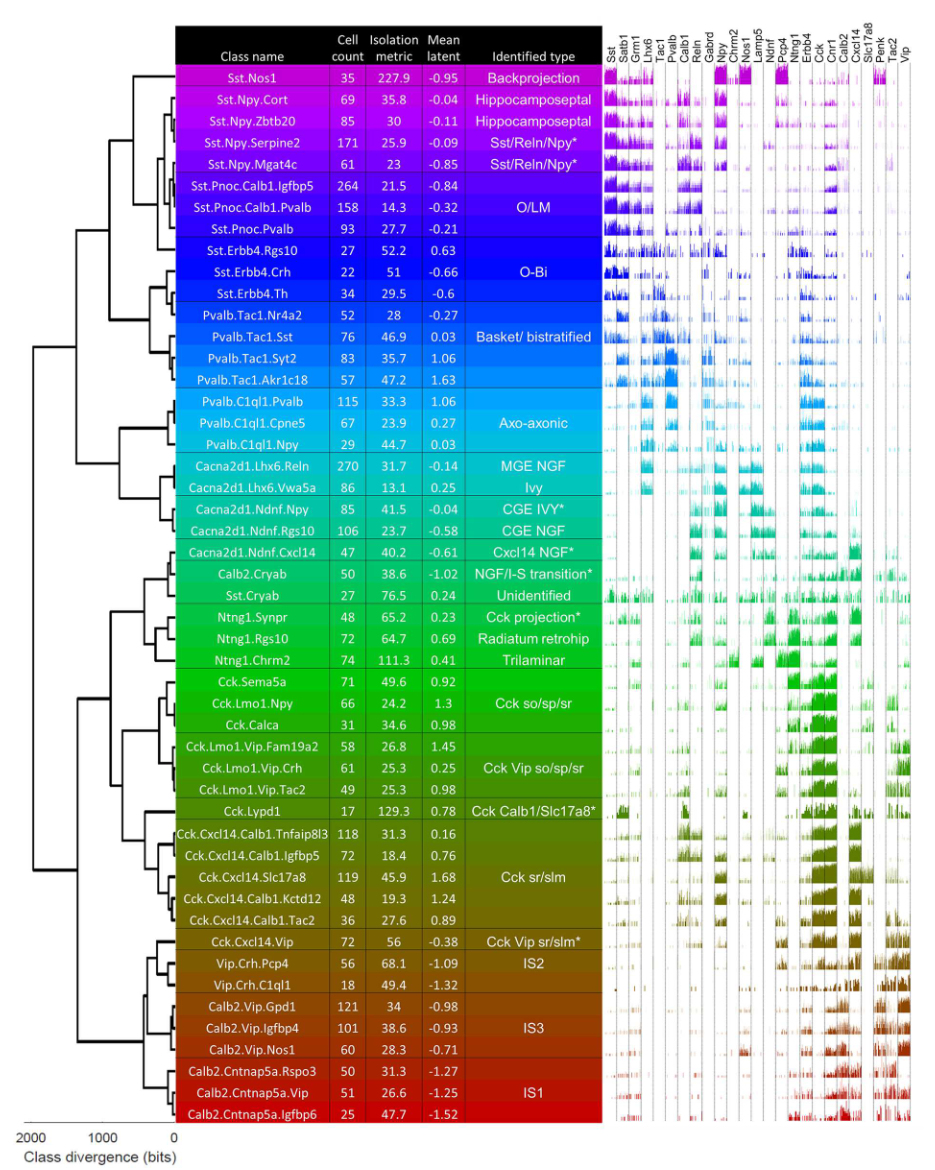

## Load data

Download the data from ILIAS, move it to the `data/` directory and unzip it there.
The read counts can be found in `counts`, with rows corresponding to cells and columns to genes.
The cluster assignments for every individual cell can be found in  `clusters`, along with the colors used in the publication in  `clusterColors`.

In [3]:
# LOAD HARRIS ET AL DATA

# Load gene counts
data = pd.read_csv("../data/nds_cl_7/harris-data/expression.tsv.gz", sep="\t")
genes = data.values[:, 0]
cells = data.columns[1:-1]
counts = data.values[:, 1:-1].transpose().astype("int")
data = []

# Kick out all genes with all counts = 0
genes = genes[counts.sum(axis=0) > 0]
counts = counts[:, counts.sum(axis=0) > 0]
print(counts.shape)

# Load clustering results
data = pd.read_csv("../data/nds_cl_7/harris-data/analysis_results.tsv", sep="\t")
clusterNames, clusters = np.unique(data.values[0, 1:-1], return_inverse=True)

# Load cluster colors
data = pd.read_csv("../data/nds_cl_7/harris-data/colormap.txt", sep="\s+", header=None)
clusterColors = data.values

# Note: the color order needs to be reversed to match the publication
clusterColors = clusterColors[::-1]

# Taken from Figure 1 - we need cluster order to get correct color order
clusterOrder = [
    "Sst.No",
    "Sst.Npy.C",
    "Sst.Npy.Z",
    "Sst.Npy.S",
    "Sst.Npy.M",
    "Sst.Pnoc.Calb1.I",
    "Sst.Pnoc.Calb1.P",
    "Sst.Pnoc.P",
    "Sst.Erbb4.R",
    "Sst.Erbb4.C",
    "Sst.Erbb4.T",
    "Pvalb.Tac1.N",
    "Pvalb.Tac1.Ss",
    "Pvalb.Tac1.Sy",
    "Pvalb.Tac1.A",
    "Pvalb.C1ql1.P",
    "Pvalb.C1ql1.C",
    "Pvalb.C1ql1.N",
    "Cacna2d1.Lhx6.R",
    "Cacna2d1.Lhx6.V",
    "Cacna2d1.Ndnf.N",
    "Cacna2d1.Ndnf.R",
    "Cacna2d1.Ndnf.C",
    "Calb2.Cry",
    "Sst.Cry",
    "Ntng1.S",
    "Ntng1.R",
    "Ntng1.C",
    "Cck.Sema",
    "Cck.Lmo1.N",
    "Cck.Calca",
    "Cck.Lmo1.Vip.F",
    "Cck.Lmo1.Vip.C",
    "Cck.Lmo1.Vip.T",
    "Cck.Ly",
    "Cck.Cxcl14.Calb1.Tn",
    "Cck.Cxcl14.Calb1.I",
    "Cck.Cxcl14.S",
    "Cck.Cxcl14.Calb1.K",
    "Cck.Cxcl14.Calb1.Ta",
    "Cck.Cxcl14.V",
    "Vip.Crh.P",
    "Vip.Crh.C1",
    "Calb2.Vip.G",
    "Calb2.Vip.I",
    "Calb2.Vip.Nos1",
    "Calb2.Cntnap5a.R",
    "Calb2.Cntnap5a.V",
    "Calb2.Cntnap5a.I",
]

reorder = np.zeros(clusterNames.size) * np.nan
for i, c in enumerate(clusterNames):
    for j, k in enumerate(clusterOrder):
        if c[: len(k)] == k:
            reorder[i] = j
            break
clusterColors = clusterColors[reorder.astype(int)]

<>:20: SyntaxWarning: invalid escape sequence '\s'
<>:20: SyntaxWarning: invalid escape sequence '\s'
<unknown>:20: SyntaxWarning: invalid escape sequence '\s'
C:\Users\carol\AppData\Local\Temp\ipykernel_47180\2453566246.py:20: SyntaxWarning: invalid escape sequence '\s'
  data = pd.read_csv("../data/nds_cl_7/harris-data/colormap.txt", sep="\s+", header=None)


(3663, 17965)


# Task 1: Data inspection
Before we use t-SNE or any other advanced visualization methods on the data, we first want to have a closer look on the data and plot some statistics. For most of the analysis we will compare the data to a Poisson distribution.

###  1.1. Relationship between expression mean and fraction of zeros
Compute actual and predicted gene expression. The higher the average expression of a gene, the smaller fraction of cells will show a 0 count. Plot the data and explain what you see in the plot.


_(3 pts)_

In [4]:
# ------------------------------------------------------
# Compute actual and predicted gene expression (1 pt)
# ------------------------------------------------------

# Compute the average expression for each gene
mean_expr = counts.mean(axis=0)

# Compute the fraction of zeros for each gene
frac_zeros = np.sum(counts == 0, axis=0) / counts.shape[0]

In [5]:
# Compute the Poisson prediction
# (what is the expected fraction of zeros in a Poisson distribution with a given mean?)
poisson_pred = np.exp(-mean_expr)

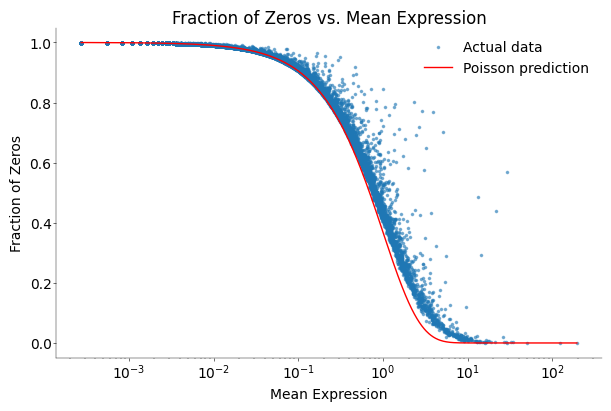

In [6]:
# --------------------------------------------------
# plot the data and the Poisson prediction (1 pt)
# --------------------------------------------------

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(mean_expr, frac_zeros, s=10, alpha=0.5, label="Actual data")
ax.plot(
    np.sort(mean_expr),
    np.exp(-np.sort(mean_expr)),
    color="red",
    label="Poisson prediction",
)
ax.set_xlabel("Mean Expression")
ax.set_ylabel("Fraction of Zeros")
ax.set_title("Fraction of Zeros vs. Mean Expression")
ax.legend()
ax.set_xscale("log")
plt.show()

_Explanation (1 pt)_

The plot shows the relationship between the average expression of a gene and the fraction of cells that show a zero count for that gene. In the plot, we can see that the fraction of cells with zero counts decreases as the average expression of the gene increases. 
- For a very low mean expression, both actual data and Poisson prediction are very close to a fraction of zeros of 1.0, and thus very similar.
- As the mean increases to an intermediate range, the actual data points show a larger fraction of zeros than what the Poisson distribution predicts.
- As the mean expression continues to increase, both actual data and Poisson prediction converge towards a fraction of zeros of 0.0.

Therefore, the zeros are the furthest away from the Poisson prediction in the intermediate range of mean expression, as expected. This is called zero-inflation of the data. 

### 1.2. Mean-variance relationship

If the expression follows Poisson distribution, then the mean should be equal to the variance. Plot the mean-variance relationship and interpret the plot.

_(2.5 pts)_

In [7]:
# -------------------------------------------------------------------
# Compute the variance of the expression counts of each gene (0.5 pt)
# -------------------------------------------------------------------

variance_expr = counts.var(axis=0)

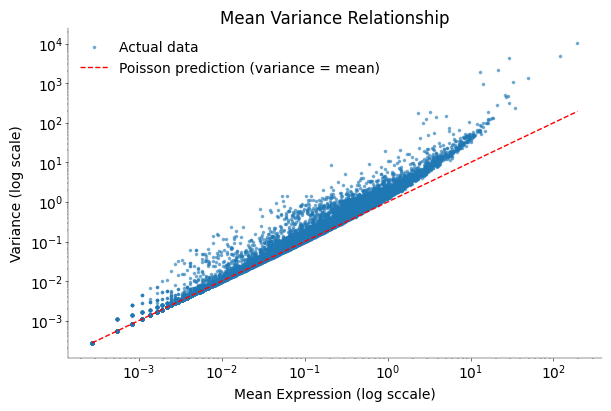

In [8]:
# -------------------------------------------------------------
# Plot the mean-variance relationship on a log-log plot (1 pt)
# Plot the Poisson prediction as a line
# -------------------------------------------------------------

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(mean_expr, variance_expr, s=10, alpha=0.5, label="Actual data")
ax.plot(
    np.sort(mean_expr),
    np.sort(mean_expr),
    color="red",
    linestyle="--",
    label="Poisson prediction (variance = mean)",
)
ax.set_xlabel("Mean Expression (log sccale)")
ax.set_ylabel("Variance (log scale)")
ax.set_title("Mean Variance Relationship")
ax.set_xscale("log")
ax.set_yscale("log")
ax.legend()
plt.show()

_Explanation (1 pt)_

In the log-log plot, we can see that the observed data points generally lie above the Poisson prediction line, which indicates that the variance is generally greater than the mean. This is called "overdispersion", it implies that the variability in gene expression is higher than what would be expected from the single random sampling alone, which is assumed by the Poisson model. The excess variance can come through biological factors and also technical factors such as varying capture efficiency. The phenomenom of "overdispersion" juggests that the Poisson model is not sufficient to describe the data. 

### 1.3. Relationship between the mean and the Fano factor

Compute the Fano factor for each gene and make a scatter plot of expression mean vs. Fano factor in log-log coordinates, and interpret what you see in the plot. If the expression follows the Poisson distribution, then the Fano factor (variance/mean) should be equal to 1 for all genes.

_(2.5 pts)_

In [9]:
# --------------------------------------------
# Compute the Fano factor for each gene (0.5 pt)
# --------------------------------------------

fano = variance_expr / mean_expr

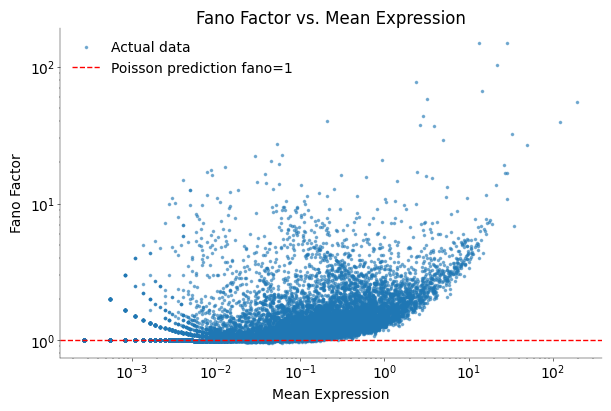

In [10]:
# -------------------------------
# plot fano-factor vs mean (1 pt)
# incl. fano factor
# -------------------------------
# Plot a Poisson prediction as line
# Use the same style of plot as above.

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(mean_expr, fano, s=10, alpha=0.5, label="Actual data")
ax.axhline(y=1, color="red", linestyle="--", label="Poisson prediction fano=1")
ax.set_xlabel("Mean Expression")
ax.set_ylabel("Fano Factor")
ax.set_title("Fano Factor vs. Mean Expression")
ax.set_xscale("log")
ax.set_yscale("log")
ax.legend()
plt.show()

_Explanation (1 pt)_

The fano factor measures the dispersion. For a Poisson distribution, it is always equal to 1, which is shown by the red line. 
We can see that the data points lie almost all above the line, and thus have a fano factor that is greater than 1. This means, as we have already seen in 1.2, that the variance for these points is greater than the mean. This confirms the overdispersion observed in 1.2, as a fano factor greater than 1 is a strong indicator for overdispersion. The plot therefore also visually demonstrates that the data is non-Poissonian. 

### 1.4. Histogram of sequencing depths

Different cells have different sequencing depths (sum of counts across all genes) because the efficiency can change from droplet to droplet due to some random expreimental factors. Make a histogram of sequencing depths.

_(1.5 pts)_

In [11]:
# -------------------------------
# Compute sequencing depth (0.5 pt)
# -------------------------------

seq_depths = counts.sum(axis=1)

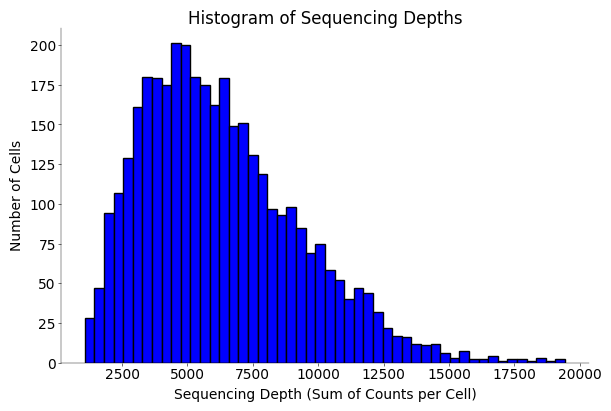

In [12]:
# ------------------------------------------
# Plot histogram of sequencing depths (1 pt)
# ------------------------------------------

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(seq_depths, bins=50, color="blue", edgecolor="black")
ax.set_xlabel("Sequencing Depth (Sum of Counts per Cell)")
ax.set_ylabel("Number of Cells")
ax.set_title("Histogram of Sequencing Depths")
plt.show()

### 1.5. Fano factors after normalization

Normalize counts by the sequencing depth of each cell and multiply by the median sequencing depth. Then make the same expression vs Fano factor plot as above. After normalization by sequencing depth, Fano factor should be closer to 1 (i.e. variance even more closely following the mean). This can be used for feature selection.

_(2.5 pts)_

In [13]:
# -------------------------------------------------
# compute normalized counts and fano factor (1 pt)
# -------------------------------------------------

median_seq_depth = np.median(seq_depths)
norm_counts = counts / seq_depths[:, np.newaxis] * median_seq_depth

norm_mean_expr = norm_counts.mean(axis=0)
norm_variance_expr = norm_counts.var(axis=0)
norm_fano = norm_variance_expr / norm_mean_expr

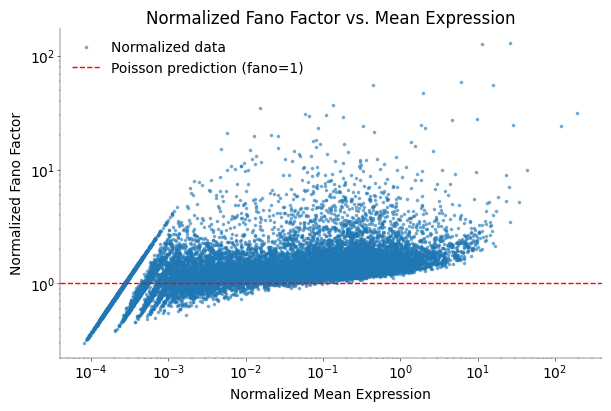

In [14]:
# ----------------------------------------------------------
# plot normalized counts and find the top 10 genes (1 pt)
# hint: keep appropriate axis scaling in mind
# ----------------------------------------------------------

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(norm_mean_expr, norm_fano, s=10, alpha=0.5, label="Normalized data")
ax.axhline(y=1, color="red", linestyle="--", label="Poisson prediction (fano=1)")
ax.set_xlabel("Normalized Mean Expression")
ax.set_ylabel("Normalized Fano Factor")
ax.set_title("Normalized Fano Factor vs. Mean Expression")
ax.set_xscale("log")
ax.set_yscale("log")
ax.legend()
plt.show()

In [15]:
# --------------------------------------------------------------------
# Find top-10 genes with the highest normalized Fano factor (0.5 pts)
# Print them sorted by the Fano factor starting from the highest
# Gene names are stored in the `genes` array
# --------------------------------------------------------------------

top_10_indices = np.argsort(norm_fano)[::-1][:10]
top_10_genes = genes[top_10_indices]
top_10_fano = norm_fano[top_10_indices]

print("\n Top 10 genes with the highest normalized Fano factor:")
for i, (gene, fano) in enumerate(zip(top_10_genes, top_10_fano)):
    print(f"{i+1}, {gene}: {fano:.2f}")


 Top 10 genes with the highest normalized Fano factor:
1, Sst: 131.14
2, Npy: 128.40
3, Vip: 59.11
4, Cck: 55.65
5, Cpne2: 55.22
6, Pcp4: 47.65
7, Ptpn23: 37.25
8, Pdzd9: 35.06
9, Malat1: 31.42
10, Armc2: 30.59


# Task 2: Low dimensional visualization

In this task we will construct a two dimensional visualization of the data. First we will normalize the data with some variance stabilizing transformation and study the effect that different approaches have on the data. Second, we will reduce the dimensionality of the data to a more feasible number of dimensions (e.g. $d=50$) using PCA. And last, we will project the PCA-reduced data to two dimensions using t-SNE.

### 2.1. PCA with and without transformations

Here we look at the influence of variance-stabilizing transformations on PCA. We will focus on the following transformations: 
- Square root (`sqrt(X)`): it is a variance-stabilizing transformation for the Poisson data. 
- Log-transform (`log2(X+1)`): it is also often used in the transcriptomic community. 

We will only work with the most important genes. For that, transform the counts into normalized counts (as above) and select all genes with normalized Fano factor above 3 and remove the rest. We will look at the effect that both transformations have in the PCA-projected data by visualizing the first two components. Interpret qualitatively what you see in the plot and compare the different embeddings making use of the ground truth clusters.

_(3.5 pts)_

In [16]:
# --------------------------------
# Select important genes (0.5 pts)
# --------------------------------

fano_threshold = 3
important_genes_indices = np.where(norm_fano > fano_threshold)[0]

important_counts = counts[:, important_genes_indices]
important_norm_counts = norm_counts[:, important_genes_indices]
important_genes_names = genes[important_genes_indices]

sqrt_counts = np.sqrt(important_counts)
log_counts = np.log2(important_counts + 1)

In [17]:
# --------------------------------------
# transform data and apply PCA (1 pt)
# --------------------------------------

from sklearn.decomposition import PCA

# perform PCA
pca = PCA(n_components=2)

pca_raw = pca.fit_transform(important_counts)
pca_sqrt = pca.fit_transform(sqrt_counts)
pca_log = pca.fit_transform(log_counts)

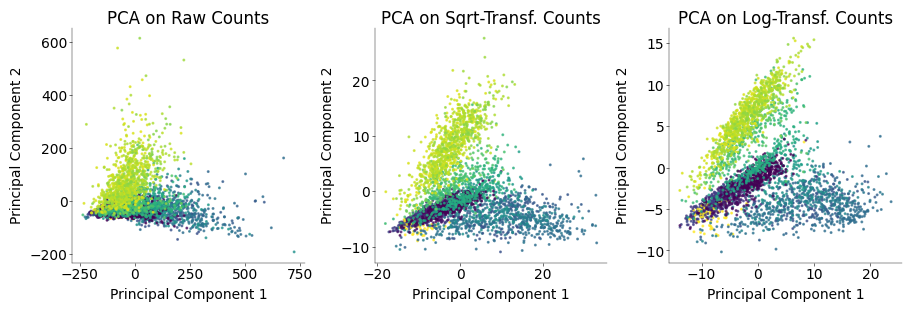

In [18]:
# ------------------------------------------------
# plot first 2 PCs for each transformation (1 pt)
# ------------------------------------------------

fig, axs = plt.subplots(1, 3, figsize=(9, 3))

# PCA on Raw Counts
scatter_raw = axs[0].scatter(
    pca_raw[:, 0], pca_raw[:, 1], c=clusters, cmap="viridis", s=5, alpha=0.7
)
axs[0].set_title("PCA on Raw Counts")
axs[0].set_xlabel("Principal Component 1")
axs[0].set_ylabel("Principal Component 2")

scatter_sqrt = axs[1].scatter(
    pca_sqrt[:, 0], pca_sqrt[:, 1], c=clusters, cmap="viridis", s=5, alpha=0.7
)
axs[1].set_title("PCA on Sqrt-Transf. Counts")
axs[1].set_xlabel("Principal Component 1")
axs[1].set_ylabel("Principal Component 2")

scatter_sqrt = axs[2].scatter(
    pca_log[:, 0], pca_log[:, 1], c=clusters, cmap="viridis", s=5, alpha=0.7
)
axs[2].set_title("PCA on Log-Transf. Counts")
axs[2].set_xlabel("Principal Component 1")
axs[2].set_ylabel("Principal Component 2")

plt.show()

_Explanation (1 pt)_

These plots show the first two principal components of the data after applying different transformations. Each color represents a ground truth cell type clusters. 
- We can see that for the untransformed, i.e. raw data, the clustering is a lot less distinct than for the two transformed datasets. This is expected, as we have already concluded in task 1 that the raw data suffers from overdispersion, which can make it harder to observe the underlying biological structures. 
- The square root transformation, which is variance-stabilizing, helps to receive a clearer representation of the data in the PCA space. 
- The log-transform (`log2(X+1)`) has an even stronger effect. The transformation helps to make the data more like a Gaussian, which is great for methods like PCA. We can see this in the plot, as the clusters are clearly more distinct. 

In conclusion, the plots allow to qualitatively compare the transformations and the raw data. The transformations, which help us to stabilize the variance, aim to reduce the strong relationship between mean and variance that can be observed in the raw data, making the variance more independent of the mean which prevents highly expressed genes from influencing the PCA disproportionally. The Log-transform works particularly well on the data, because it is able to stabilize the variance across a wide range of counts. 

It is important to remark that the plots only show the separation in 2D. While the transformations already improve the separation in 2D, a higher number of principal components might be needed to achieve a more accurate separation of the underlying clusters. 

### 2.2. tSNE with and without transformations

Now, we will reduce the dimensionality of the PCA-reduced data further to two dimensions using t-SNE. We will use only $n=50$ components of the PCA-projected data. Plot the t-SNE embedding for the three versions of the data and interpret the plots. Do the different transformations have any effect on t-SNE?

_(1.5 pts)_

In [19]:
# -----------------------
# Perform tSNE (0.5 pts)
# -----------------------

n_components_pca = 50
pca_full = PCA(n_components=n_components_pca)

# PCA on raw important counts for tSNE
pca_raw_tsne_input = pca_full.fit_transform(important_counts)

# PCA on square root tranformed important counts for tSNE
pca_sqrt_tsne_input = pca_full.fit_transform(sqrt_counts)

# PCA on log transformed important counts for tSNE
pca_log_tsne_input = pca_full.fit_transform(log_counts)

# tSNE
tsne = TSNE(n_components=2, random_state=42, verbose=False)

tsne_raw = tsne.fit(pca_raw_tsne_input)
tsne_sqrt = tsne.fit(pca_sqrt_tsne_input)
tsne_log = tsne.fit(pca_log_tsne_input)

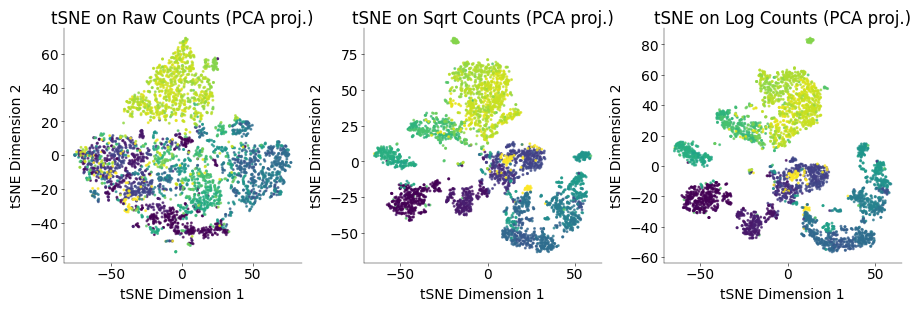

In [25]:
# -----------------------------------------------
# plot t-SNE embedding for each dataset (1 pt)
# -----------------------------------------------

fig, axs = plt.subplots(1, 3, figsize=(9, 3))

# Raw counts tSNE
axs[0].scatter(
    tsne_raw[:, 0], tsne_raw[:, 1], c=clusters, cmap="viridis", s=5, alpha=0.7
)
axs[0].set_title("tSNE on Raw Counts (PCA proj.)")
axs[0].set_xlabel("tSNE Dimension 1")
axs[0].set_ylabel("tSNE Dimension 2")

# Sqrt-transformed counts tSNE
axs[1].scatter(
    tsne_sqrt[:, 0], tsne_sqrt[:, 1], c=clusters, cmap="viridis", s=5, alpha=0.7
)
axs[1].set_title("tSNE on Sqrt Counts (PCA proj.)")
axs[1].set_xlabel("tSNE Dimension 1")
axs[1].set_ylabel("tSNE Dimension 2")

# Log-transformed counts tSNE
axs[2].scatter(
    tsne_log[:, 0], tsne_log[:, 1], c=clusters, cmap="viridis", s=5, alpha=0.7
)
axs[2].set_title("tSNE on Log Counts (PCA proj.)")
axs[2].set_xlabel("tSNE Dimension 1")
axs[2].set_ylabel("tSNE Dimension 2")

plt.show()

### 2.3. Leiden clustering

Now we will play around with some clustering and see whether the clustering methods can produce similar results to the original clusters from the publication. We will apply Leiden clustering (closely related to the Louvain clustering), which is standard in the field and works well even for very large datasets. 

Choose one representation of the data (best transformation based in your results from the previous task) to use further in this task and justify your choice. Think about which level of dimensionality would be sensible to use to perform clustering. Visualize in the two-dimensional embedding the resulting clusters and compare to the original clusters. 

_(1.5 pts)_

In [23]:
# To run this code you need to install leidenalg and igraph
# conda install -c conda-forge python-igraph leidenalg

import igraph as ig
from sklearn.neighbors import NearestNeighbors, kneighbors_graph
import leidenalg as la

In [24]:
# Define some contrast colors

clusterCols = [
    "#FFFF00",
    "#1CE6FF",
    "#FF34FF",
    "#FF4A46",
    "#008941",
    "#006FA6",
    "#A30059",
    "#FFDBE5",
    "#7A4900",
    "#0000A6",
    "#63FFAC",
    "#B79762",
    "#004D43",
    "#8FB0FF",
    "#997D87",
    "#5A0007",
    "#809693",
    "#FEFFE6",
    "#1B4400",
    "#4FC601",
    "#3B5DFF",
    "#4A3B53",
    "#FF2F80",
    "#61615A",
    "#BA0900",
    "#6B7900",
    "#00C2A0",
    "#FFAA92",
    "#FF90C9",
    "#B903AA",
    "#D16100",
    "#DDEFFF",
    "#000035",
    "#7B4F4B",
    "#A1C299",
    "#300018",
    "#0AA6D8",
    "#013349",
    "#00846F",
    "#372101",
    "#FFB500",
    "#C2FFED",
    "#A079BF",
    "#CC0744",
    "#C0B9B2",
    "#C2FF99",
    "#001E09",
    "#00489C",
    "#6F0062",
    "#0CBD66",
    "#EEC3FF",
    "#456D75",
    "#B77B68",
    "#7A87A1",
    "#788D66",
    "#885578",
    "#FAD09F",
    "#FF8A9A",
    "#D157A0",
    "#BEC459",
    "#456648",
    "#0086ED",
    "#886F4C",
    "#34362D",
    "#B4A8BD",
    "#00A6AA",
    "#452C2C",
    "#636375",
    "#A3C8C9",
    "#FF913F",
    "#938A81",
    "#575329",
    "#00FECF",
    "#B05B6F",
    "#8CD0FF",
    "#3B9700",
    "#04F757",
    "#C8A1A1",
    "#1E6E00",
    "#7900D7",
    "#A77500",
    "#6367A9",
    "#A05837",
    "#6B002C",
    "#772600",
    "#D790FF",
    "#9B9700",
    "#549E79",
    "#FFF69F",
    "#201625",
    "#72418F",
    "#BC23FF",
    "#99ADC0",
    "#3A2465",
    "#922329",
    "#5B4534",
    "#FDE8DC",
    "#404E55",
    "#0089A3",
    "#CB7E98",
    "#A4E804",
    "#324E72",
    "#6A3A4C",
    "#83AB58",
    "#001C1E",
    "#D1F7CE",
    "#004B28",
    "#C8D0F6",
    "#A3A489",
    "#806C66",
    "#222800",
    "#BF5650",
    "#E83000",
    "#66796D",
    "#DA007C",
    "#FF1A59",
    "#8ADBB4",
    "#1E0200",
    "#5B4E51",
    "#C895C5",
    "#320033",
    "#FF6832",
    "#66E1D3",
    "#CFCDAC",
    "#D0AC94",
    "#7ED379",
    "#012C58",
]

clusterCols = np.array(clusterCols)

In [27]:
# ------------------------------------------------------
# create graph and run leiden clustering on it (0.5 pts)
# hint: use `la?`, `la.find_partition?` and `ig.Graph?`
# to find out more about the provided packages.
# ------------------------------------------------------

chosen_representation = pca_log_tsne_input  # in 2.3, we have seen that this is the representation that leads to the best results

# Construct kNN graph with k=15
k = 15
A = kneighbors_graph(chosen_representation, k, metric="euclidean")

# Transform it into an igraph object
sources, targets = A.nonzero()
graph = ig.Graph(n=chosen_representation.shape[0], edges=list(zip(sources, targets)))

# Run Leiden clustering
# you can use `la.RBConfigurationVertexPartition` as the partition type
partition = la.find_partition(graph, la.RBConfigurationVertexPartition)
leiden_clusters = np.array(partition.membership)

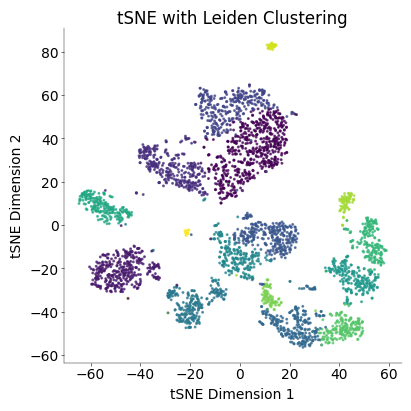

In [29]:
# --------------------------
# Plot the results (1 pt)
# --------------------------

fig, ax = plt.subplots(figsize=(4, 4))
scatter = ax.scatter(
    tsne_log[:, 0], tsne_log[:, 1], c=leiden_clusters, cmap="viridis", s=5, alpha=0.7
)
ax.set_title("tSNE with Leiden Clustering")
ax.set_xlabel("tSNE Dimension 1")
ax.set_ylabel("tSNE Dimension 2")
plt.show()

### 2.4. Change the clustering resolution

The number of clusters can be changed by modifying the resolution parameter. How many clusters did we get with the default value? Change the resolution parameter to yield 2x more and 2x fewer clusters
Plot all three results as t-SNE overlays (same as above).

_(1.5 pts)_

In [33]:
# ------------------------------------------------------------------
# run the clustering for 3 different resolution parameters (0.5 pts)
# ------------------------------------------------------------------

def cluster_with_resolution(res_val, G):
    partition = la.find_partition(
        G, la.RBConfigurationVertexPartition, resolution_parameter=res_val
    )
    leiden_clusters = np.array(partition.membership)
    n_leiden_clusters = len(np.unique(leiden_clusters))
    return partition, leiden_clusters, n_leiden_clusters


# resolution 1.0
partition_normal, leiden_clusters_normal, n_leiden_clusters_normal = (
    cluster_with_resolution(1.0, graph)
)
print(f"Number of clusters with resolution 1.0: {n_leiden_clusters_normal}")

# resolution 0.5
partition_fewer, leiden_clusters_fewer, n_leiden_clusters_fewer = (
    cluster_with_resolution(0.5, graph)
)
print(f"Number of clusters with resolution 0.5: {n_leiden_clusters_fewer}")

# resolution 2.0
partition_more, leiden_clusters_more, n_leiden_clusters_more = cluster_with_resolution(
    2.0, graph
)
print(f"Number of clusters with resolution 2.0: {n_leiden_clusters_more}")

Number of clusters with resolution 1.0: 15
Number of clusters with resolution 0.5: 10
Number of clusters with resolution 2.0: 23


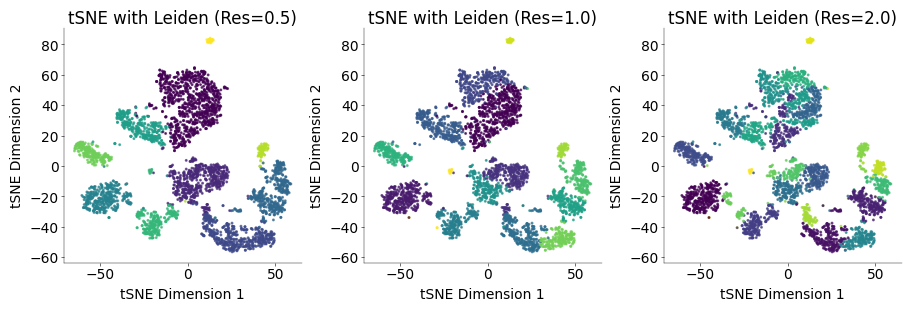

In [38]:
# --------------------------
# Plot the results (1 pt)
# --------------------------

fig, axs = plt.subplots(1, 3, figsize=(9, 3))

# resolution 0.5
scatter_fewer = axs[0].scatter(
    tsne_log[:, 0], tsne_log[:, 1], c=leiden_clusters_fewer, s=5, alpha=0.7
)
axs[0].set_xlabel("tSNE Dimension 1")
axs[0].set_ylabel("tSNE Dimension 2")
axs[0].set_title(f"tSNE with Leiden (Res=0.5)")

# resolution 1.0
scatter_normal = axs[1].scatter(
    tsne_log[:, 0], tsne_log[:, 1], c=leiden_clusters_normal, s=5, alpha=0.7
)
axs[1].set_xlabel("tSNE Dimension 1")
axs[1].set_ylabel("tSNE Dimension 2")
axs[1].set_title(f"tSNE with Leiden (Res=1.0)")

# resolution 0.5
scatter_more = axs[2].scatter(
    tsne_log[:, 0], tsne_log[:, 1], c=leiden_clusters_more, s=5, alpha=0.7
)
axs[2].set_xlabel("tSNE Dimension 1")
axs[2].set_ylabel("tSNE Dimension 2")
axs[2].set_title(f"tSNE with Leiden (Res=2.0)")

plt.show()